In [25]:
#importing necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [26]:
#Loading the dataset
df=pd.read_csv(r"D:\AI\ML\Projects\train_u6lujuX_CVtuZ9i (1) (1).csv")
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [27]:
# Data Processing
print(df.shape)
print(df.describe())

(614, 13)
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [28]:
#Checking for the null values
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [29]:
#Improving the null values
df.fillna(method='ffill', inplace=True)
df.fillna(df['LoanAmount'].mean(), inplace=True)
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\shtsu\AppData\Local\Temp\ipykernel_35668\352609865.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [30]:
#Label Encoding for all categorical values
label=LabelEncoder()
df['Married']=label.fit_transform(df['Married'])
df['Gender']=label.fit_transform(df['Gender'])
df['Education']=label.fit_transform(df['Education'])
df['Self_Employed']=label.fit_transform(df['Self_Employed'])
df['Loan_Status']=label.fit_transform(df['Loan_Status'])
print(df.head())


    Loan_ID  Gender  Married Dependents  Education  Self_Employed  \
0  LP001002       1        0          0          0              0   
1  LP001003       1        1          1          0              0   
2  LP001005       1        1          0          0              1   
3  LP001006       1        1          0          1              0   
4  LP001008       1        0          0          0              0   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  147.381729             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area  Loan_Status  
0             1.0         Urban            1  
1             1.0         Rural            0  
2             1.0

In [31]:
#Checking different possibles values 
print(df['Dependents'].value_counts())

Dependents
0     354
2     105
1     104
3+     51
Name: count, dtype: int64


In [39]:
#Checking different possibles values 
print(df['Property_Area'].value_counts())

print("Label encoding for the property area:")
df.replace({'Property_Area':{'Semiurban':0,'Urban':1,'Rural':2}}, inplace=True)
print(df)

Property_Area
0    233
1    202
2    179
Name: count, dtype: int64
Label encoding for the property area:
      Loan_ID  Gender  Married Dependents  Education  Self_Employed  \
0    LP001002       1        0          0          0              0   
1    LP001003       1        1          1          0              0   
2    LP001005       1        1          0          0              1   
3    LP001006       1        1          0          1              0   
4    LP001008       1        0          0          0              0   
..        ...     ...      ...        ...        ...            ...   
609  LP002978       0        0          0          0              0   
610  LP002979       1        1          4          0              0   
611  LP002983       1        1          1          0              0   
612  LP002984       1        1          2          0              0   
613  LP002990       0        0          0          0              1   

     ApplicantIncome  CoapplicantIncome  L

In [40]:
#Changing 3+ notation into 4 for better readbility
df=df.replace(to_replace='3+', value=4)
print(df['Dependents'].value_counts())

Dependents
0    354
2    105
1    104
4     51
Name: count, dtype: int64


<Axes: xlabel='Education', ylabel='count'>

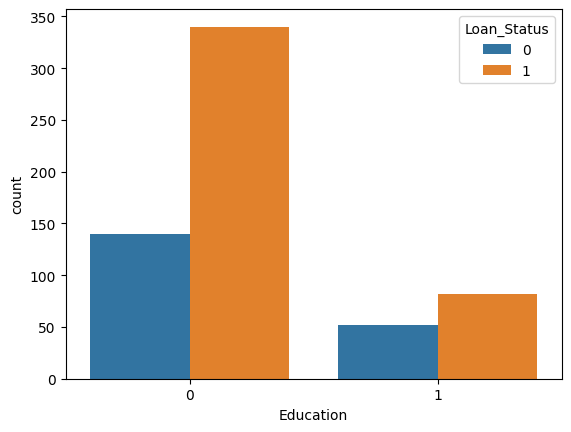

In [41]:
#Visualization of the data
#Education vs loan status
sns.countplot(x='Education', hue='Loan_Status', data=df)

<Axes: xlabel='Gender', ylabel='count'>

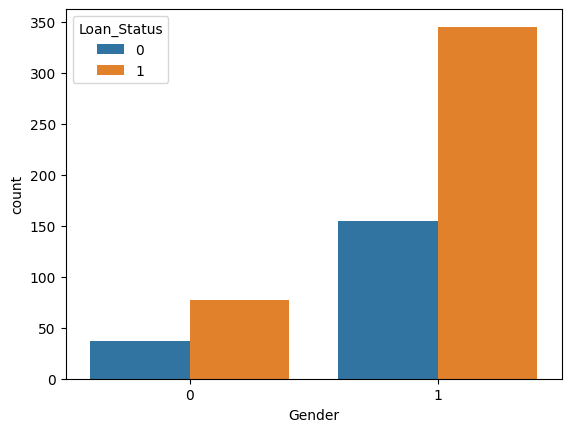

In [42]:
#Gender vs Loan status
sns.countplot(x='Gender', hue='Loan_Status', data=df)

In [43]:
#Separating data and label
X=df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']
print(X)
print(y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0          0          0              0             5849   
1         1        1          1          0              0             4583   
2         1        1          0          0              1             3000   
3         1        1          0          1              0             2583   
4         1        0          0          0              0             6000   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          0              0             2900   
610       1        1          4          0              0             4106   
611       1        1          1          0              0             8072   
612       1        1          2          0              0             7583   
613       0        0          0          0              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [59]:
#Scaling the data
scale = StandardScaler()

cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
X[cols] = scale.fit_transform(X[cols])

print(X)


     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0          0          0              0         0.072991   
1         1        1          1          0              0        -0.134412   
2         1        1          0          0              1        -0.393747   
3         1        1          0          1              0        -0.462062   
4         1        0          0          0              0         0.097728   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          0              0        -0.410130   
610       1        1          4          0              0        -0.212557   
611       1        1          1          0              0         0.437174   
612       1        1          2          0              0         0.357064   
613       0        0          0          0              1        -0.134412   

     CoapplicantIncome    LoanAmount  Loan_Amount_Term  Credit_

In [48]:
#Splitting data into training and testing data
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
print(X_train.shape)
print(X_test.shape)

(491, 11)
(123, 11)


In [60]:
#Training the model
model=LogisticRegression()
model.fit(X_train,y_train)

C:\Users\shtsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
#Model evaluaition
y_train_predicted=model.predict(X_train)
train_data_acc=mean_squared_error(y_train_predicted,y_train)
print(train_data_acc)

0.20366598778004075


In [62]:
#Model evaluaition
y_train_predicted=model.predict(X_test)
test_data_acc=mean_squared_error(y_train_predicted,y_test)
print(test_data_acc)

0.14634146341463414


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on numeric training columns (replace X_train with your training data)
scaler.fit(X_train[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']])


,copy,True
,with_mean,True
,with_std,True


In [79]:
import numpy as np

input_data = (1,0,0,1,0,1853,2840,114,360,1,3)
data = np.asarray(input_data).reshape(1, -1)

scale_idx = [5, 6, 7, 8]  # indices of numeric columns to scale

data_scaled = data.copy()
data_scaled[:, scale_idx] = scaler.transform(data[:, scale_idx])

print(data_scaled)


[[1 0 0 1 0 0 0 0 0 1 3]]


C:\Users\shtsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [80]:
#Checking the model with single data
output=model.predict(data_scaled)

if output==1:
    print('Loan Granted')
else:
    print('Loan Not Granted')

Loan Granted


C:\Users\shtsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
